In [ ]:
!pip install "numpy<2" scikit-surprise --force-reinstall --quiet
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 5.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 14.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load files
!wget https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
!unzip ml-latest-small.zip

movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = pd.read_csv("ml-latest-small/ratings.csv")
tags = pd.read_csv("ml-latest-small/tags.csv")
links = pd.read_csv("ml-latest-small/links.csv")

# Quick check
print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)
print("Tags shape:", tags.shape)
print("Links shape:", links.shape)

movies.head()

--2026-04-29 02:16:18--  https://files.grouplens.org/datasets/movielens/ml-latest-small.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 978202 (955K) [application/zip]
Saving to: ‘ml-latest-small.zip’

ml-latest-small.zip 100%[===================>] 955.28K  4.27MB/s    in 0.2s    

2026-04-29 02:16:18 (4.27 MB/s) - ‘ml-latest-small.zip’ saved [978202/978202]

Archive:  ml-latest-small.zip
   creating: ml-latest-small/
  inflating: ml-latest-small/links.csv  
  inflating: ml-latest-small/tags.csv  
  inflating: ml-latest-small/ratings.csv  
  inflating: ml-latest-small/README.txt  
  inflating: ml-latest-small/movies.csv  
Movies shape: (9742, 3)
Ratings shape: (100836, 4)
Tags shape: (3683, 4)
Links shape: (9742, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


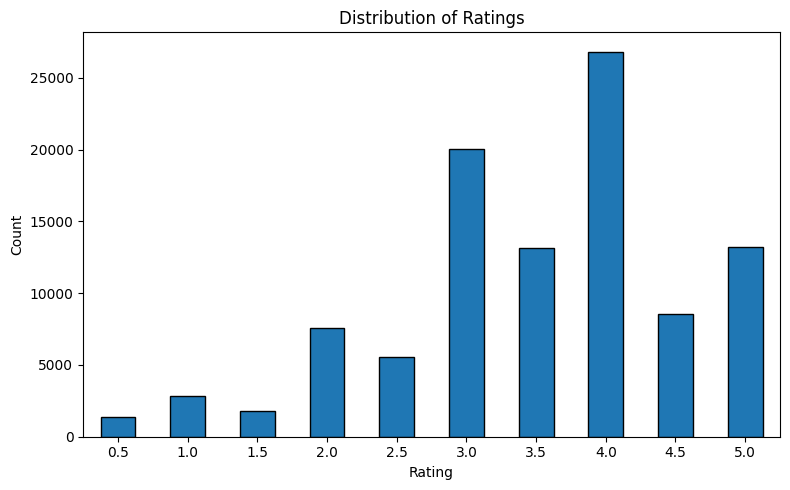

In [ ]:
plt.figure(figsize=(8, 5))
ratings["rating"].value_counts().sort_index().plot(kind="bar", edgecolor="black")
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

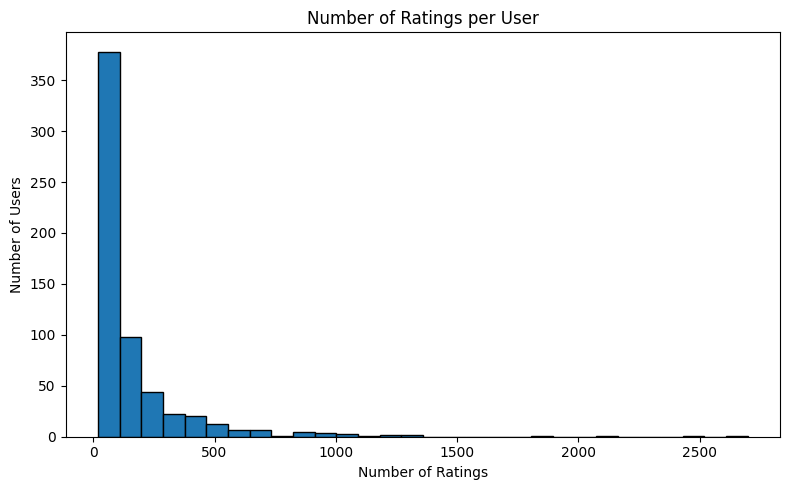

In [ ]:
ratings_per_user = ratings.groupby("userId")["rating"].count()

plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=30, edgecolor="black")
plt.title("Number of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()

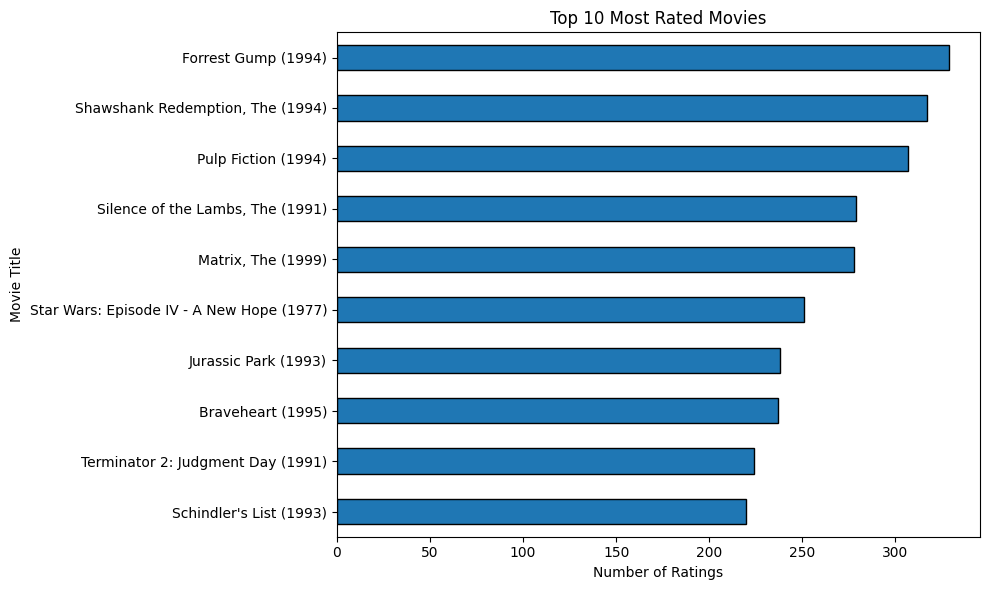

In [ ]:
ratings_movies = ratings.merge(movies, on="movieId", how="left")

movie_rating_counts = (
    ratings_movies.groupby("title")["rating"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
movie_rating_counts.sort_values().plot(kind="barh", edgecolor="black")
plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie Title")
plt.tight_layout()
plt.show()


In [ ]:
print("Missing values in movies:")
print(movies.isnull().sum())

print("\nMissing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in tags:")
print(tags.isnull().sum())

print("\nMissing values in links:")
print(links.isnull().sum())

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in tags:
userId       0
movieId      0
tag          0
timestamp    0
dtype: int64

Missing values in links:
movieId    0
imdbId     0
tmdbId     8
dtype: int64


In [ ]:
from surprise import Dataset, Reader
# Data Pre-Processing

# 1. Remove duplicates
ratings = ratings.drop_duplicates()
movies = movies.drop_duplicates()
tags = tags.drop_duplicates()
links = links.drop_duplicates()

# 2. Filter sparse users and movies
user_counts = ratings["userId"].value_counts()
movie_counts = ratings["movieId"].value_counts()

ratings = ratings[ratings["userId"].isin(user_counts[user_counts >= 10].index)]
ratings = ratings[ratings["movieId"].isin(movie_counts[movie_counts >= 10].index)]

print("Ratings shape after filtering:", ratings.shape)

# 3. Clean movie titles
movies["title"] = movies["title"].str.replace(r"\(\d{4}\)", "", regex=True).str.strip()

# 4. Normalize ratings using mean center
ratings["rating_norm"] = ratings.groupby("userId")["rating"].transform(lambda x: x - x.mean())
data = Dataset.load_from_df(ratings[["userId", "movieId", "rating_norm"]], Reader)

Ratings shape after filtering: (81116, 4)


In [ ]:
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

# Each movie has a pipe-separated genres string, e.g. "Action|Adventure|Sci-Fi"
# We split those into lists and binarise them into a genre indicator matrix.

mlb = MultiLabelBinarizer()

genre_lists = movies["genres"].str.split("|").tolist()
genre_matrix = mlb.fit_transform(genre_lists)   # shape: (n_movies, n_genres)
genre_df = pd.DataFrame(genre_matrix,
                         columns=mlb.classes_,
                         index=movies["movieId"])

print(f"Genre matrix shape: {genre_df.shape}")
print("Genres encoded:", list(mlb.classes_))
genre_df.head()

Genre matrix shape: (9742, 20)
Genres encoded: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,,,
1,0,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
def get_content_based_recommendations(seed_titles, n=10, exclude_seeds=True):
    """
    Recommend movies similar to a list of seed titles using one-hot genre encoding.
    seed_titles : list[str]  Movie titles (or partial titles) to seed from.
    n           : int        Number of recommendations to return.
    exclude_seeds: bool      If True, seed movies are excluded from results.
    Returns pd.DataFrame with columns: movieId, title, genres, similarity_score
    """
    # --- resolve seed titles to movieIds ---------------------------------
    seed_ids = []
    for title in seed_titles:
        matches = movies[movies["title"].str.contains(title, case=False, na=False)]
        if matches.empty:
            for article in ["The ", "A ", "An "]:
                if title.startswith(article):
                    remainder = title[len(article):]
                    matches = movies[movies["title"].str.contains(remainder, case=False, na=False)]
                    if not matches.empty:
                        break
        chosen = matches.iloc[0]
        seed_ids.append(chosen["movieId"])
        print(f"  Matched '{title}' → '{chosen['title']}'")

    if not seed_ids:
        print("  Available sample titles:")
        print(movies["title"].sample(10).tolist())
        raise ValueError("None of the seed titles matched any movie in the dataset.")

    # --- build average genre profile -------------------------------------
    seed_vectors = genre_df.loc[genre_df.index.isin(seed_ids)].values.astype(float)
    taste_profile = seed_vectors.mean(axis=0, keepdims=True)  # shape: (1, n_genres)

    # --- compute cosine similarity to all movies -------------------------
    sims = cosine_similarity(taste_profile, genre_df.values.astype(float)).flatten()

    # --- assemble results ------------------------------------------------
    result = movies.copy()
    result["similarity_score"] = sims
    if exclude_seeds:
        result = result[~result["movieId"].isin(seed_ids)]
    result = result.sort_values("similarity_score", ascending=False).head(n).reset_index(drop=True)
    return result[["movieId", "title", "genres", "similarity_score"]]


# Example: recommend from a few movies
recs = get_content_based_recommendations(["Toy Story", "Finding Nemo", "Shrek"], n=10)
print(recs.to_string(index=False))

# Works with even a single movie
recs_single = get_content_based_recommendations(["The Matrix"], n=10)
print(recs_single.to_string(index=False))


  Matched 'Toy Story' → 'Toy Story'
  Matched 'Finding Nemo' → 'Finding Nemo'
  Matched 'Shrek' → 'Shrek'
 movieId                                            title                                      genres  similarity_score
   53121                                  Shrek the Third Adventure|Animation|Children|Comedy|Fantasy          0.977802
    4016                        Emperor's New Groove, The Adventure|Animation|Children|Comedy|Fantasy          0.977802
    4886                                   Monsters, Inc. Adventure|Animation|Children|Comedy|Fantasy          0.977802
    2294                                             Antz Adventure|Animation|Children|Comedy|Fantasy          0.977802
   91355 Asterix and the Vikings (Astérix et les Vikings) Adventure|Animation|Children|Comedy|Fantasy          0.977802
    3114                                      Toy Story 2 Adventure|Animation|Children|Comedy|Fantasy          0.977802
   45074                                        Wild, 

In [ ]:
from surprise import SVD
from surprise.model_selection import train_test_split, cross_validate, GridSearchCV
from surprise import accuracy, dump
import pandas as pd

# The code below will train a model via SVD collaborative filtering.
# It learns latent factors (hidden representations of users and movies) from data
# It optimizes a loss function (minimizing RMSE between predicted and actual ratings) via gradient descent
# It generalizes to predict ratings for user-movie pairs it hasn't seen before
# It has hyperparameters to tune (number of factors, learning rate, regularization)

# ── 1. Load data into Surprise format ──────────────────────────────────────────
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(ratings[["userId", "movieId", "rating"]], reader)

# ── 2. Train/test split ────────────────────────────────────────────────────────
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

# ── 3. Train SVD ───────────────────────────────────────────────────────────────
svd = SVD(n_factors=150, n_epochs=30, lr_all=0.01, reg_all=0.01, random_state=42)
svd.fit(trainset)

# ── 4. Evaluate ────────────────────────────────────────────────────────────────
predictions = svd.test(testset)
print(f"RMSE: {accuracy.rmse(predictions):.4f}")
print(f"MAE:  {accuracy.mae(predictions):.4f}")

# ── 5. (Optional) Cross-validation for more robust evaluation ─────────────────
cv_results = cross_validate(svd, data, measures=["RMSE", "MAE"], cv=5, verbose=True)
print(f"\nMean RMSE: {cv_results['test_rmse'].mean():.4f}")
print(f"Mean MAE:  {cv_results['test_mae'].mean():.4f}")

# ── 6. (Optional) Hyperparameter tuning ───────────────────────────────────────
# This gave these parameters as best: n_factors=150, n_epochs=30, lr_all=0.01, reg_all=0.1
# Only a few values were tested; need to use randomized search or bayesian optimization to
# find the actual truly best parameters
# param_grid = {
#     "n_factors": [50, 100, 150],
#     "n_epochs":  [20, 30],
#     "lr_all":    [0.005, 0.01],
#     "reg_all":   [0.02, 0.1],
# }
# gs = GridSearchCV(SVD, param_grid, measures=["rmse"], cv=3, n_jobs=-1)
# gs.fit(data)
# print(f"\nBest RMSE: {gs.best_score['rmse']:.4f}")
# print(f"Best params: {gs.best_params['rmse']}")

# ── 7. Predict a single user-movie rating ─────────────────────────────────────
uid = 1      # userId
iid = 318    # movieId (318 = Shawshank Redemption)
pred = svd.predict(uid, iid)
print(f"\nPredicted rating for user {uid}, movie {iid}: {pred.est:.2f}")

# ── 8. Generate top-N recommendations for a user ──────────────────────────────
def get_top_n_recommendations(model, user_id, movies_df, ratings_df, n=10):
    # Movies the user has already rated
    rated_movie_ids = ratings_df[ratings_df["userId"] == user_id]["movieId"].tolist()

    # Predict ratings for all unrated movies
    all_movie_ids = movies_df["movieId"].tolist()
    unrated = [mid for mid in all_movie_ids if mid not in rated_movie_ids]
    predictions = [model.predict(user_id, mid) for mid in unrated]

    # Sort by predicted rating and return top N
    top_n = sorted(predictions, key=lambda x: x.est, reverse=True)[:n]
    top_movie_ids = [p.iid for p in top_n]

    result = movies_df[movies_df["movieId"].isin(top_movie_ids)].copy()
    result = result.set_index("movieId")
    for p in top_n:
      result.loc[p.iid, "predicted_rating"] = p.est

    result = result.reset_index().sort_values("predicted_rating", ascending=False)
    return result.sort_values("predicted_rating", ascending=False)

# Example
top_movies = get_top_n_recommendations(svd, user_id=1, movies_df=movies, ratings_df=ratings)
print("\nTop 10 recommendations for user 1:")
print(top_movies[["title", "genres", "predicted_rating"]].to_string(index=False))

# See what user 1 actually rated
user1_ratings = ratings[ratings["userId"] == 1]
print(user1_ratings["rating"].describe())

top_movies = get_top_n_recommendations(svd, user_id=2, movies_df=movies, ratings_df=ratings)
print("\nTop 10 recommendations for user 2:")
print(top_movies[["title", "genres", "predicted_rating"]].to_string(index=False))

# See what user 2 actually rated
user2_ratings = ratings[ratings["userId"] == 2]
print(user2_ratings["rating"].describe())

top_movies = get_top_n_recommendations(svd, user_id=3, movies_df=movies, ratings_df=ratings)
print("\nTop 10 recommendations for user 3:")
print(top_movies[["title", "genres", "predicted_rating"]].to_string(index=False))

# See what user 3 actually rated
user3_ratings = ratings[ratings["userId"] == 3]
print(user3_ratings["rating"].describe())

# Dump the model so we don't have to retrain
dump.dump("svd_model.pkl", algo=svd)

RMSE: 0.8804
RMSE: 0.8804
MAE:  0.6767
MAE:  0.6767
Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.8787  0.8724  0.8791  0.8800  0.8773  0.8775  0.0027  
MAE (testset)     0.6748  0.6700  0.6732  0.6787  0.6701  0.6734  0.0032  
Fit time          2.13    2.24    2.81    2.08    2.06    2.26    0.28    
Test time         0.23    0.15    0.10    0.09    0.23    0.16    0.06    

Mean RMSE: 0.8775
Mean MAE:  0.6734

Predicted rating for user 1, movie 318: 4.31

Top 10 recommendations for user 1:
                                                   title                                 genres  predicted_rating
                                   Sense and Sensibility                          Drama|Romance               5.0
                                              Persuasion                          Drama|Romance               5.0
City of Lost Children, The (Cité des enfants perdus, La) A

In [ ]:
from google.colab import files

# Download the trained model
dump.dump("svd_model.pkl", algo=svd)
files.download("svd_model.pkl")

# Download the data files
files.download("ml-latest-small/movies.csv")
files.download("ml-latest-small/ratings.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>